In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# 1. Load cleaned data
cleaned_data = pd.read_csv("cleaned_market_data.csv", parse_dates=["Date"])

# 2. Sort properly
cleaned_data = cleaned_data.sort_values(["Ticker", "Date"]).reset_index(drop=True)

# 3. Compute daily returns from Adjusted Close
cleaned_data["Daily Return"] = cleaned_data.groupby("Ticker")["Adj Close"].pct_change()

# 4. Inspect output
print(cleaned_data.head(15))
print("\nShape:", cleaned_data.shape)

print("\nMissing values in Daily Return:")
print(cleaned_data["Daily Return"].isna().sum())

print("\nNaN count per ticker in Daily Return:")
print(cleaned_data.groupby("Ticker")["Daily Return"].apply(lambda x: x.isna().sum()))

         Date      Ticker         Open         High          Low        Close  \
0  2023-01-02  APOLLOHOSP  4488.000000  4516.700195  4446.000000  4454.350098   
1  2023-01-03  APOLLOHOSP  4467.000000  4508.950195  4425.100098  4490.899902   
2  2023-01-04  APOLLOHOSP  4495.000000  4514.100098  4425.000000  4433.299805   
3  2023-01-05  APOLLOHOSP  4455.500000  4455.500000  4356.000000  4429.049805   
4  2023-01-06  APOLLOHOSP  4442.049805  4474.299805  4369.000000  4387.450195   
5  2023-01-09  APOLLOHOSP  4424.350098  4452.149902  4381.049805  4407.700195   
6  2023-01-10  APOLLOHOSP  4410.000000  4489.000000  4406.000000  4466.649902   
7  2023-01-11  APOLLOHOSP  4474.000000  4482.450195  4336.049805  4360.600098   
8  2023-01-12  APOLLOHOSP  4370.950195  4382.399902  4325.250000  4359.750000   
9  2023-01-13  APOLLOHOSP  4365.000000  4370.000000  4268.049805  4335.549805   
10 2023-01-16  APOLLOHOSP  4364.250000  4364.250000  4285.000000  4294.649902   
11 2023-01-17  APOLLOHOSP  4

In [4]:
returns_data = cleaned_data[["Date", "Ticker", "Adj Close", "Daily Return"]].copy()

# 2. Separate stocks and benchmark
stock_returns = returns_data[returns_data["Ticker"] != "NIFTY50"].copy()
benchmark_returns = returns_data[returns_data["Ticker"] == "NIFTY50"].copy()

# 3. Rename benchmark return column
benchmark_returns = benchmark_returns[["Date", "Daily Return"]].rename(
    columns={"Daily Return": "NIFTY50_Return"}
)

# 4. Inspect
print("Stock returns shape:", stock_returns.shape)
print("Benchmark returns shape:", benchmark_returns.shape)

print("\nStock returns sample:")
print(stock_returns.head(10))

print("\nBenchmark returns sample:")
print(benchmark_returns.head(10))

print("\nUnique stock tickers:")
print(sorted(stock_returns["Ticker"].unique()))

print("\nNumber of stock tickers:", stock_returns["Ticker"].nunique())

Stock returns shape: (7365, 4)
Benchmark returns shape: (491, 2)

Stock returns sample:
        Date      Ticker    Adj Close  Daily Return
0 2023-01-02  APOLLOHOSP  4411.582520           NaN
1 2023-01-03  APOLLOHOSP  4447.780762      0.008205
2 2023-01-04  APOLLOHOSP  4390.733887     -0.012826
3 2023-01-05  APOLLOHOSP  4386.524902     -0.000959
4 2023-01-06  APOLLOHOSP  4345.324707     -0.009392
5 2023-01-09  APOLLOHOSP  4365.379883      0.004615
6 2023-01-10  APOLLOHOSP  4423.763672      0.013374
7 2023-01-11  APOLLOHOSP  4318.731934     -0.023743
8 2023-01-12  APOLLOHOSP  4317.890625     -0.000195
9 2023-01-13  APOLLOHOSP  4293.922363     -0.005551

Benchmark returns sample:
           Date  NIFTY50_Return
4910 2023-01-02             NaN
4911 2023-01-03        0.001929
4912 2023-01-04       -0.010399
4913 2023-01-05       -0.002815
4914 2023-01-06       -0.007376
4915 2023-01-09        0.013536
4916 2023-01-10       -0.010334
4917 2023-01-11       -0.001030
4918 2023-01-12       -0.

In [5]:
returns_data = cleaned_data[["Date", "Ticker", "Adj Close", "Daily Return"]].copy()

# 2. Separate stocks and benchmark
stock_returns = returns_data[returns_data["Ticker"] != "NIFTY50"].copy()
benchmark_returns = returns_data[returns_data["Ticker"] == "NIFTY50"].copy()

# 3. Rename benchmark return column
benchmark_returns = benchmark_returns[["Date", "Daily Return"]].rename(
    columns={"Daily Return": "NIFTY50_Return"}
)

# 4. Inspect
print("Stock returns shape:", stock_returns.shape)
print("Benchmark returns shape:", benchmark_returns.shape)

print("\nStock returns sample:")
print(stock_returns.head(10))

print("\nBenchmark returns sample:")
print(benchmark_returns.head(10))

print("\nUnique stock tickers:")
print(sorted(stock_returns["Ticker"].unique()))

print("\nNumber of stock tickers:", stock_returns["Ticker"].nunique())


Stock returns shape: (7365, 4)
Benchmark returns shape: (491, 2)

Stock returns sample:
        Date      Ticker    Adj Close  Daily Return
0 2023-01-02  APOLLOHOSP  4411.582520           NaN
1 2023-01-03  APOLLOHOSP  4447.780762      0.008205
2 2023-01-04  APOLLOHOSP  4390.733887     -0.012826
3 2023-01-05  APOLLOHOSP  4386.524902     -0.000959
4 2023-01-06  APOLLOHOSP  4345.324707     -0.009392
5 2023-01-09  APOLLOHOSP  4365.379883      0.004615
6 2023-01-10  APOLLOHOSP  4423.763672      0.013374
7 2023-01-11  APOLLOHOSP  4318.731934     -0.023743
8 2023-01-12  APOLLOHOSP  4317.890625     -0.000195
9 2023-01-13  APOLLOHOSP  4293.922363     -0.005551

Benchmark returns sample:
           Date  NIFTY50_Return
4910 2023-01-02             NaN
4911 2023-01-03        0.001929
4912 2023-01-04       -0.010399
4913 2023-01-05       -0.002815
4914 2023-01-06       -0.007376
4915 2023-01-09        0.013536
4916 2023-01-10       -0.010334
4917 2023-01-11       -0.001030
4918 2023-01-12       -0.

In [6]:
TRADING_DAYS = 252
RISK_FREE_RATE = 0.065  # 6.5% per annum

# Keep only stock rows and drop the first NaN return row of each ticker
stock_returns_clean = stock_returns.dropna(subset=["Daily Return"]).copy()

# Group by ticker and compute metrics
metrics_basic = stock_returns_clean.groupby("Ticker").agg(
    mean_daily_return=("Daily Return", "mean"),
    std_daily_return=("Daily Return", "std"),
    n_days=("Daily Return", "count")
).reset_index()

# Annualised return from mean daily return
metrics_basic["Annualised Return (%)"] = metrics_basic["mean_daily_return"] * TRADING_DAYS * 100

# Annualised volatility
metrics_basic["Annualised Volatility (%)"] = metrics_basic["std_daily_return"] * np.sqrt(TRADING_DAYS) * 100

# Sharpe ratio
metrics_basic["Sharpe Ratio"] = (
    (metrics_basic["mean_daily_return"] * TRADING_DAYS - RISK_FREE_RATE)
    / (metrics_basic["std_daily_return"] * np.sqrt(TRADING_DAYS))
)
# Keep only the main columns for now
metrics_basic = metrics_basic[
    ["Ticker", "n_days", "Annualised Return (%)", "Annualised Volatility (%)", "Sharpe Ratio"]
]

# Round for display
metrics_basic_display = metrics_basic.copy()
metrics_basic_display["Annualised Return (%)"] = metrics_basic_display["Annualised Return (%)"].round(2)
metrics_basic_display["Annualised Volatility (%)"] = metrics_basic_display["Annualised Volatility (%)"].round(2)
metrics_basic_display["Sharpe Ratio"] = metrics_basic_display["Sharpe Ratio"].round(3)

print(metrics_basic_display)

        Ticker  n_days  Annualised Return (%)  Annualised Volatility (%)  \
0   APOLLOHOSP     490                  28.03                      21.74   
1     AXISBANK     490                   8.81                      21.90   
2        CIPLA     490                  22.04                      24.07   
3     DIVISLAB     490                  34.65                      26.26   
4      DRREDDY     490                  28.03                      19.45   
5      HCLTECH     490                  37.86                      21.37   
6     HDFCBANK     490                   7.62                      19.80   
7    ICICIBANK     490                  20.59                      18.34   
8         INFY     490                  16.42                      23.09   
9    KOTAKBANK     490                   1.10                      20.47   
10        SBIN     490                  18.59                      25.57   
11   SUNPHARMA     490                  35.34                      17.37   
12         T

In [7]:
# 1. Merge each stock's daily return with NIFTY50 daily return by date
beta_data = stock_returns.merge(benchmark_returns, on="Date", how="left")

# 2. Drop rows where either stock return or benchmark return is missing
beta_data = beta_data.dropna(subset=["Daily Return", "NIFTY50_Return"]).copy()

# 3. Check merged data
print(beta_data.head(10))
print("\nShape:", beta_data.shape)

print("\nMissing values after merge:")
print(beta_data[["Daily Return", "NIFTY50_Return"]].isna().sum())

         Date      Ticker    Adj Close  Daily Return  NIFTY50_Return
1  2023-01-03  APOLLOHOSP  4447.780762      0.008205        0.001929
2  2023-01-04  APOLLOHOSP  4390.733887     -0.012826       -0.010399
3  2023-01-05  APOLLOHOSP  4386.524902     -0.000959       -0.002815
4  2023-01-06  APOLLOHOSP  4345.324707     -0.009392       -0.007376
5  2023-01-09  APOLLOHOSP  4365.379883      0.004615        0.013536
6  2023-01-10  APOLLOHOSP  4423.763672      0.013374       -0.010334
7  2023-01-11  APOLLOHOSP  4318.731934     -0.023743       -0.001030
8  2023-01-12  APOLLOHOSP  4317.890625     -0.000195       -0.002095
9  2023-01-13  APOLLOHOSP  4293.922363     -0.005551        0.005510
10 2023-01-16  APOLLOHOSP  4253.415039     -0.009434       -0.003439

Shape: (7350, 5)

Missing values after merge:
Daily Return      0
NIFTY50_Return    0
dtype: int64


In [8]:
beta_results = []

for ticker, group in beta_data.groupby("Ticker"):
    cov_matrix = np.cov(group["Daily Return"], group["NIFTY50_Return"])
    beta = cov_matrix[0, 1] / cov_matrix[1, 1]
    
    beta_results.append({
        "Ticker": ticker,
        "Beta vs NIFTY50": beta
    })

beta_df = pd.DataFrame(beta_results)
beta_df["Beta vs NIFTY50"] = beta_df["Beta vs NIFTY50"].round(3)

print(beta_df.sort_values("Beta vs NIFTY50", ascending=False))

beta_df.to_csv("beta_df.csv", index=False)
print("\nSaved file: beta_df.csv")

        Ticker  Beta vs NIFTY50
10        SBIN            1.391
14       WIPRO            1.073
1     AXISBANK            1.060
6     HDFCBANK            1.039
7    ICICIBANK            0.970
8         INFY            0.902
13       TECHM            0.873
9    KOTAKBANK            0.863
5      HCLTECH            0.787
12         TCS            0.747
0   APOLLOHOSP            0.564
11   SUNPHARMA            0.473
3     DIVISLAB            0.453
4      DRREDDY            0.429
2        CIPLA            0.332

Saved file: beta_df.csv


In [9]:
print("\nHighest beta stocks:")
print(beta_df.sort_values("Beta vs NIFTY50", ascending=False).head())

print("\nLowest beta stocks:")
print(beta_df.sort_values("Beta vs NIFTY50", ascending=True).head())


Highest beta stocks:
       Ticker  Beta vs NIFTY50
10       SBIN            1.391
14      WIPRO            1.073
1    AXISBANK            1.060
6    HDFCBANK            1.039
7   ICICIBANK            0.970

Lowest beta stocks:
        Ticker  Beta vs NIFTY50
2        CIPLA            0.332
4      DRREDDY            0.429
3     DIVISLAB            0.453
11   SUNPHARMA            0.473
0   APOLLOHOSP            0.564


In [10]:
drawdown_results = []

for ticker, group in stock_returns.groupby("Ticker"):
    group = group.sort_values("Date").copy()
    
    # cumulative wealth index starting at 1
    group["Cumulative"] = (1 + group["Daily Return"].fillna(0)).cumprod()
    
    # running peak
    group["Running Peak"] = group["Cumulative"].cummax()
    
    # drawdown
    group["Drawdown"] = (group["Cumulative"] / group["Running Peak"]) - 1
    
    max_drawdown = group["Drawdown"].min() * 100  # convert to %
    
    drawdown_results.append({
        "Ticker": ticker,
        "Maximum Drawdown (%)": max_drawdown
    })

drawdown_df = pd.DataFrame(drawdown_results)
drawdown_df["Maximum Drawdown (%)"] = drawdown_df["Maximum Drawdown (%)"].round(2)

print(drawdown_df.sort_values("Maximum Drawdown (%)"))

        Ticker  Maximum Drawdown (%)
8         INFY                -24.34
9    KOTAKBANK                -23.15
5      HCLTECH                -21.66
3     DIVISLAB                -21.45
2        CIPLA                -20.77
6     HDFCBANK                -19.91
14       WIPRO                -19.53
1     AXISBANK                -19.18
10        SBIN                -17.48
13       TECHM                -16.22
4      DRREDDY                -15.61
0   APOLLOHOSP                -14.87
12         TCS                -13.17
11   SUNPHARMA                -12.24
7    ICICIBANK                 -9.45


In [11]:
print("\nWorst drawdowns:")
print(drawdown_df.sort_values("Maximum Drawdown (%)").head())

print("\nLeast severe drawdowns:")
print(drawdown_df.sort_values("Maximum Drawdown (%)", ascending=False).head())


Worst drawdowns:
      Ticker  Maximum Drawdown (%)
8       INFY                -24.34
9  KOTAKBANK                -23.15
5    HCLTECH                -21.66
3   DIVISLAB                -21.45
2      CIPLA                -20.77

Least severe drawdowns:
        Ticker  Maximum Drawdown (%)
7    ICICIBANK                 -9.45
11   SUNPHARMA                -12.24
12         TCS                -13.17
0   APOLLOHOSP                -14.87
4      DRREDDY                -15.61


In [12]:
# Work on a fresh copy
sma_data = stock_returns[["Date", "Ticker", "Adj Close"]].copy()
sma_data = sma_data.sort_values(["Ticker", "Date"]).reset_index(drop=True)

# Compute rolling SMAs
sma_data["SMA_50"] = sma_data.groupby("Ticker")["Adj Close"].transform(
    lambda x: x.rolling(window=50).mean()
)

sma_data["SMA_200"] = sma_data.groupby("Ticker")["Adj Close"].transform(
    lambda x: x.rolling(window=200).mean()
)

# Keep the latest row for each stock
latest_sma = sma_data.groupby("Ticker").tail(1).copy()

# Select only final columns
sma_summary = latest_sma[["Ticker", "Date", "Adj Close", "SMA_50", "SMA_200"]].copy()

# Round for display
sma_summary["Adj Close"] = sma_summary["Adj Close"].round(2)
sma_summary["SMA_50"] = sma_summary["SMA_50"].round(2)
sma_summary["SMA_200"] = sma_summary["SMA_200"].round(2)

print(sma_summary.sort_values("Ticker"))

          Ticker       Date  Adj Close   SMA_50  SMA_200
490   APOLLOHOSP 2024-12-31    7267.08  7056.82  6565.78
981     AXISBANK 2024-12-31    1063.79  1143.20  1160.50
1472       CIPLA 2024-12-31    1512.84  1486.84  1493.14
1963    DIVISLAB 2024-12-31    6071.16  5902.24  4851.42
2454     DRREDDY 2024-12-31    1379.75  1264.83  1268.54
2945     HCLTECH 2024-12-31    1833.88  1793.46  1560.20
3436    HDFCBANK 2024-12-31     874.60   877.13   805.41
3927   ICICIBANK 2024-12-31    1271.84  1283.17  1189.13
4418        INFY 2024-12-31    1825.96  1824.44  1650.15
4909   KOTAKBANK 2024-12-31     356.80   351.79   353.39
5400        SBIN 2024-12-31     779.30   811.96   795.25
5891   SUNPHARMA 2024-12-31    1856.84  1789.58  1662.53
6382         TCS 2024-12-31    3886.50  3988.15  3898.83
6873       TECHM 2024-12-31    1658.22  1666.05  1441.97
7364       WIPRO 2024-12-31     282.95   272.50   244.27


In [13]:
# Optional: quick signal check
sma_summary["SMA Signal"] = sma_summary.apply(
    lambda row: "Bullish (50 > 200)" if row["SMA_50"] > row["SMA_200"] else "Bearish (50 <= 200)",
    axis=1
)

print(sma_summary[["Ticker", "Adj Close", "SMA_50", "SMA_200", "SMA Signal"]].sort_values("Ticker"))

          Ticker  Adj Close   SMA_50  SMA_200           SMA Signal
490   APOLLOHOSP    7267.08  7056.82  6565.78   Bullish (50 > 200)
981     AXISBANK    1063.79  1143.20  1160.50  Bearish (50 <= 200)
1472       CIPLA    1512.84  1486.84  1493.14  Bearish (50 <= 200)
1963    DIVISLAB    6071.16  5902.24  4851.42   Bullish (50 > 200)
2454     DRREDDY    1379.75  1264.83  1268.54  Bearish (50 <= 200)
2945     HCLTECH    1833.88  1793.46  1560.20   Bullish (50 > 200)
3436    HDFCBANK     874.60   877.13   805.41   Bullish (50 > 200)
3927   ICICIBANK    1271.84  1283.17  1189.13   Bullish (50 > 200)
4418        INFY    1825.96  1824.44  1650.15   Bullish (50 > 200)
4909   KOTAKBANK     356.80   351.79   353.39  Bearish (50 <= 200)
5400        SBIN     779.30   811.96   795.25   Bullish (50 > 200)
5891   SUNPHARMA    1856.84  1789.58  1662.53   Bullish (50 > 200)
6382         TCS    3886.50  3988.15  3898.83   Bullish (50 > 200)
6873       TECHM    1658.22  1666.05  1441.97   Bullish (50 > 

In [14]:
# Start from the basic metrics table
task2_summary = metrics_basic[[
    "Ticker",
    "Annualised Return (%)",
    "Annualised Volatility (%)",
    "Sharpe Ratio"
]].copy()

# Merge Beta
task2_summary = task2_summary.merge(beta_df, on="Ticker", how="left")

# Merge Maximum Drawdown
task2_summary = task2_summary.merge(drawdown_df, on="Ticker", how="left")

# Merge SMA values only
task2_summary = task2_summary.merge(
    sma_summary[["Ticker", "SMA_50", "SMA_200"]],
    on="Ticker",
    how="left"
)

# Round final display columns
task2_summary["Annualised Return (%)"] = task2_summary["Annualised Return (%)"].round(2)
task2_summary["Annualised Volatility (%)"] = task2_summary["Annualised Volatility (%)"].round(2)
task2_summary["Sharpe Ratio"] = task2_summary["Sharpe Ratio"].round(3)
task2_summary["Beta vs NIFTY50"] = task2_summary["Beta vs NIFTY50"].round(3)
task2_summary["Maximum Drawdown (%)"] = task2_summary["Maximum Drawdown (%)"].round(2)
task2_summary["SMA_50"] = task2_summary["SMA_50"].round(2)
task2_summary["SMA_200"] = task2_summary["SMA_200"].round(2)

# Sort by ticker
task2_summary = task2_summary.sort_values("Ticker").reset_index(drop=True)

print(task2_summary)

        Ticker  Annualised Return (%)  Annualised Volatility (%)  \
0   APOLLOHOSP                  28.03                      21.74   
1     AXISBANK                   8.81                      21.90   
2        CIPLA                  22.04                      24.07   
3     DIVISLAB                  34.65                      26.26   
4      DRREDDY                  28.03                      19.45   
5      HCLTECH                  37.86                      21.37   
6     HDFCBANK                   7.62                      19.80   
7    ICICIBANK                  20.59                      18.34   
8         INFY                  16.42                      23.09   
9    KOTAKBANK                   1.10                      20.47   
10        SBIN                  18.59                      25.57   
11   SUNPHARMA                  35.34                      17.37   
12         TCS                  16.41                      19.71   
13       TECHM                  33.44           

In [15]:
task2_summary.to_csv("task2_summary_table.csv", index=False)
task2_summary.to_excel("task2_summary_table.xlsx", index=False)

print("Saved:")
print("- task2_summary_table.csv")
print("- task2_summary_table.xlsx")

Saved:
- task2_summary_table.csv
- task2_summary_table.xlsx


In [16]:
print("\nTop 5 by Sharpe Ratio:")
print(task2_summary.sort_values("Sharpe Ratio", ascending=False).head())

print("\nTop 5 by Annualised Return:")
print(task2_summary.sort_values("Annualised Return (%)", ascending=False).head())

print("\nLowest drawdown risk:")
print(task2_summary.sort_values("Maximum Drawdown (%)", ascending=False).head())


Top 5 by Sharpe Ratio:
       Ticker  Annualised Return (%)  Annualised Volatility (%)  Sharpe Ratio  \
11  SUNPHARMA                  35.34                      17.37         1.660   
5     HCLTECH                  37.86                      21.37         1.468   
4     DRREDDY                  28.03                      19.45         1.107   
3    DIVISLAB                  34.65                      26.26         1.072   
13      TECHM                  33.44                      25.16         1.071   

    Beta vs NIFTY50  Maximum Drawdown (%)   SMA_50  SMA_200  
11            0.473                -12.24  1789.58  1662.53  
5             0.787                -21.66  1793.46  1560.20  
4             0.429                -15.61  1264.83  1268.54  
3             0.453                -21.45  5902.24  4851.42  
13            0.873                -16.22  1666.05  1441.97  

Top 5 by Annualised Return:
        Ticker  Annualised Return (%)  Annualised Volatility (%)  \
5      HCLTECH      

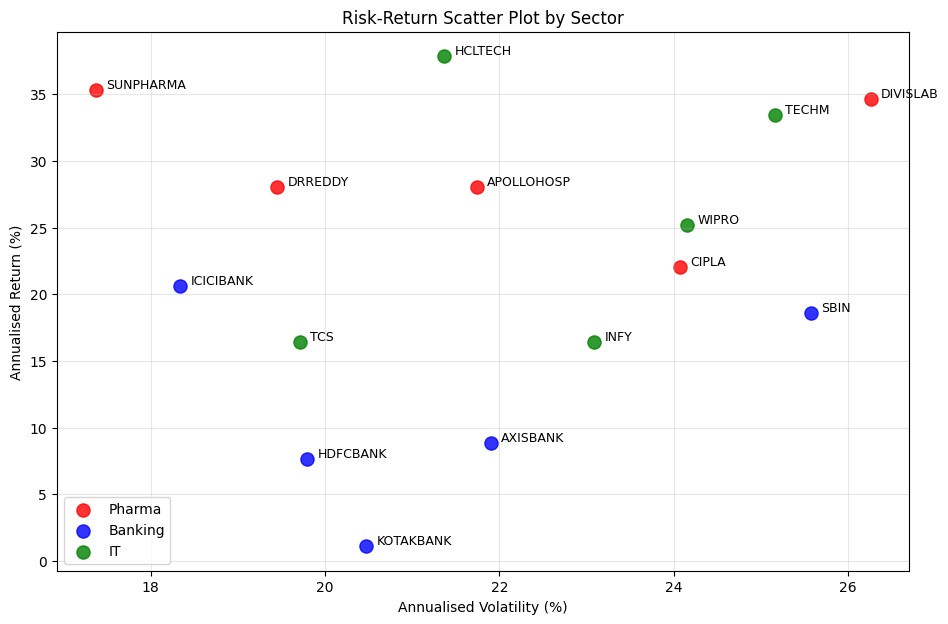

Saved: risk_return_scatter_colored.png


In [17]:
# Sector mapping
sector_map = {
    "HDFCBANK": "Banking",
    "ICICIBANK": "Banking",
    "SBIN": "Banking",
    "KOTAKBANK": "Banking",
    "AXISBANK": "Banking",
    "TCS": "IT",
    "INFY": "IT",
    "WIPRO": "IT",
    "HCLTECH": "IT",
    "TECHM": "IT",
    "SUNPHARMA": "Pharma",
    "DRREDDY": "Pharma",
    "CIPLA": "Pharma",
    "DIVISLAB": "Pharma",
    "APOLLOHOSP": "Pharma"
}

# Add sector column
plot_data = task2_summary.copy()
plot_data["Sector"] = plot_data["Ticker"].map(sector_map)

# Color mapping
color_map = {
    "Banking": "blue",
    "IT": "green",
    "Pharma": "red"
}

plt.figure(figsize=(11, 7))

# Plot each sector separately
for sector in plot_data["Sector"].unique():
    sector_df = plot_data[plot_data["Sector"] == sector]
    plt.scatter(
        sector_df["Annualised Volatility (%)"],
        sector_df["Annualised Return (%)"],
        label=sector,
        color=color_map[sector],
        s=90,
        alpha=0.8
    )

# Add ticker labels
for _, row in plot_data.iterrows():
    plt.text(
        row["Annualised Volatility (%)"] + 0.12,
        row["Annualised Return (%)"] + 0.12,
        row["Ticker"],
        fontsize=9
    )

plt.title("Risk-Return Scatter Plot by Sector")
plt.xlabel("Annualised Volatility (%)")
plt.ylabel("Annualised Return (%)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig("risk_return_scatter_colored.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: risk_return_scatter_colored.png")

In [18]:
# Create wide return table: rows = Date, columns = Ticker
returns_matrix = stock_returns.pivot(
    index="Date",
    columns="Ticker",
    values="Daily Return"
)

# Correlation matrix
corr_matrix = returns_matrix.corr()

print(corr_matrix.round(3))

Ticker      APOLLOHOSP  AXISBANK  CIPLA  DIVISLAB  DRREDDY  HCLTECH  HDFCBANK  \
Ticker                                                                          
APOLLOHOSP       1.000     0.149  0.226     0.258    0.216    0.207     0.093   
AXISBANK         0.149     1.000  0.092     0.080    0.062    0.133     0.395   
CIPLA            0.226     0.092  1.000     0.274    0.359    0.058     0.007   
DIVISLAB         0.258     0.080  0.274     1.000    0.286    0.151     0.035   
DRREDDY          0.216     0.062  0.359     0.286    1.000    0.183     0.134   
HCLTECH          0.207     0.133  0.058     0.151    0.183    1.000     0.113   
HDFCBANK         0.093     0.395  0.007     0.035    0.134    0.113     1.000   
ICICIBANK        0.120     0.590  0.066     0.024    0.015    0.128     0.422   
INFY             0.100     0.107  0.078     0.126    0.187    0.663     0.171   
KOTAKBANK        0.158     0.290  0.048     0.055   -0.007    0.142     0.379   
SBIN             0.176     0

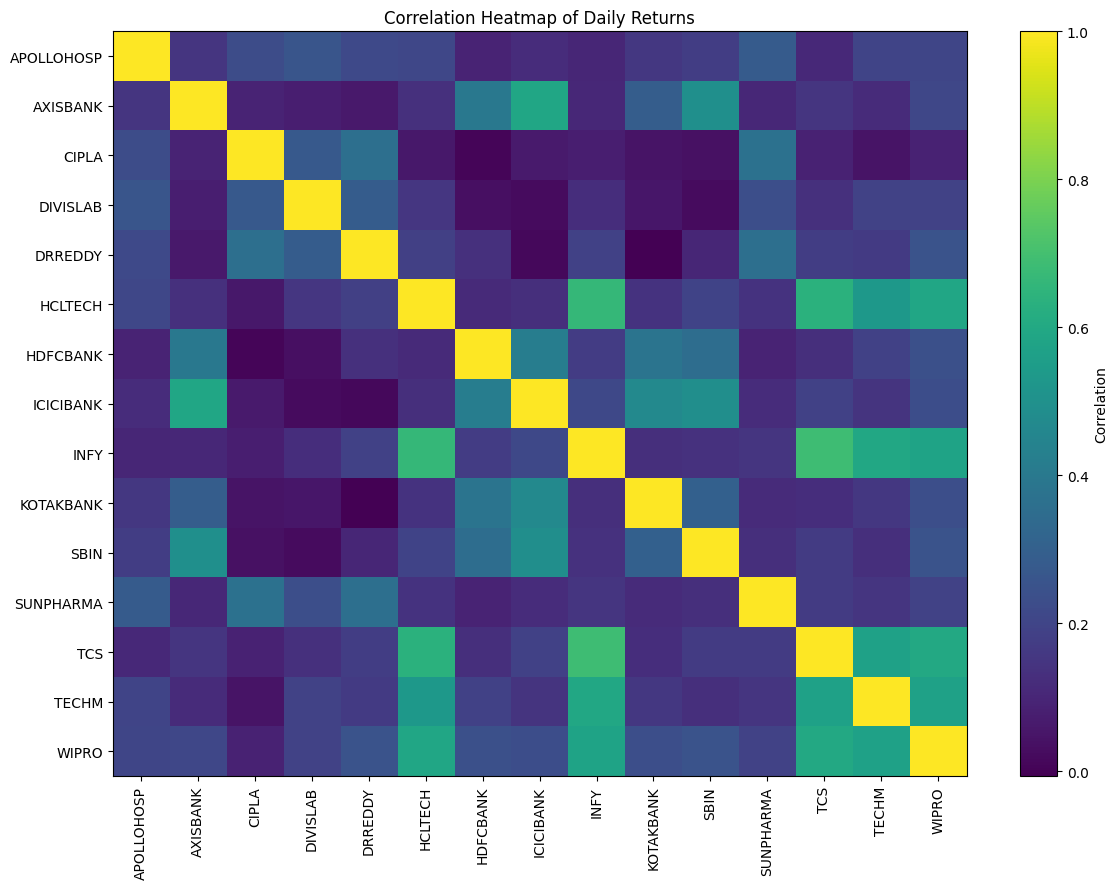

Saved: correlation_heatmap.png


In [19]:
plt.figure(figsize=(12, 9))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)

plt.title("Correlation Heatmap of Daily Returns")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: correlation_heatmap.png")

In [20]:
corr_pairs = corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool))
max_corr = corr_pairs.unstack().dropna().sort_values(ascending=False)

print(max_corr.head(10))

Ticker   Ticker 
TCS      INFY       0.687035
INFY     TCS        0.687035
HCLTECH  INFY       0.662560
INFY     HCLTECH    0.662560
TCS      HCLTECH    0.635031
HCLTECH  TCS        0.635031
WIPRO    TCS        0.601597
TCS      WIPRO      0.601597
TECHM    INFY       0.596359
INFY     TECHM      0.596359
dtype: float64
